# Book Recommendation

Every book reader probably knows this problem: What do i read next? In this notebook i will build a recommendation system to recommend books using three different approaches. For this we will use the [Book Recommendation Dataset](https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset/data)

## Content

- [Load and Check Data](#load-and-check-data)

## Load and Check Data

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
books_df=pd.read_csv('./../Datasets/bookRecommendationDataset/Books.csv')
users_df = pd.read_csv('./../Datasets/bookRecommendationDataset/Users.csv')
ratings_df = pd.read_csv('./../Datasets/bookRecommendationDataset/Ratings.csv')

C:\Users\kyild\AppData\Local\Temp\ipykernel_16012\810213482.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books_df=pd.read_csv('./../Datasets/bookRecommendationDataset/Books.csv')


In [3]:
books_df.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [133]:
users_df.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [134]:
ratings_df.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [4]:
books_df=pd.merge(books_df,ratings_df,how='inner',on='ISBN')
books_df.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,User-ID,Book-Rating
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,2,0
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,8,5
2,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,11400,0
3,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,11676,8
4,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,41385,0


<Axes: >

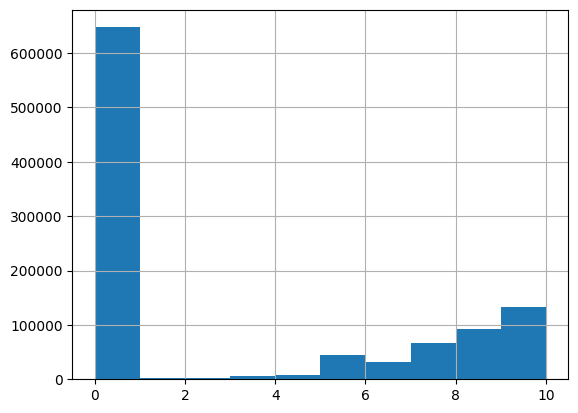

In [136]:
#distribution of book ratings
books_df['Book-Rating'].hist()

In [137]:
books_df.isnull().sum()
books_df.dropna(inplace=True)

In [ ]:
books_df.groupby('Book-Rating')['User-ID'].count().reset_index()

,Book-Rating,User-ID
0,0,647294
1,1,1481
2,2,2375
3,3,5118
4,4,7617
5,5,45355
6,6,31687
7,7,66402
8,8,91804
9,9,60778


### Popularity based Recommendation

The most basics recommendation system is recommending the most popular books to the user, since these are popular for a reason.

In [114]:
books_df.groupby("Book-Title")["Book-Rating"].mean().sort_values(ascending=False).head()

Book-Title
touch the flame                                                                                                          10.0
 Dark Justice                                                                                                            10.0
'Isms: a dictionary of words ending in -ism, -ology, and -phobia,: With some similar terms, arranged in subject order    10.0
Ã? sucesso solo 50 anni fa: Lo sterminio di sei milioni di Ebrei                                                         10.0
'California Historical Landmarks'                                                                                        10.0
Name: Book-Rating, dtype: float64

Well these answers don't make much sense since i have never heard of these books before. Most likely these books have low rating count but high ratings. To avoid this I will determine the popular books.

In [115]:
rating_count=books_df.groupby("Book-Title").count()["Book-Rating"].reset_index()
rating_count.rename(columns={"Book-Rating":"VotingCount"},inplace=True)
rating_average=books_df.groupby("Book-Title")["Book-Rating"].mean().reset_index()
rating_average.rename(columns={"Book-Rating":"AverageRating"},inplace=True)
popular_books_df=rating_count.merge(rating_average,on='Book-Title')
C=popular_books_df["AverageRating"].mean()
m=popular_books_df["VotingCount"].quantile(0.90)
def weighted_rate(x):
    v=x["VotingCount"]
    R=x["AverageRating"]
    
    return ((v*R) + (m*C)) / (v+m)
popular_books_df=popular_books_df[popular_books_df["VotingCount"]>=250]
popular_books_df["Popularity"] = popular_books_df.apply(weighted_rate,axis=1)
popular_books_df.sort_values(by="AverageRating",ascending=False).reset_index(drop=True).head(10) # Puts out the 10 most popular books

,Book-Title,VotingCount,AverageRating,Popularity
0,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804,5.805129
1,Harry Potter and the Goblet of Fire (Book 4),387,5.824289,5.772160
2,Harry Potter and the Sorcerer's Stone (Book 1),278,5.737410,5.667477
3,Harry Potter and the Order of the Phoenix (Boo...,347,5.501441,5.449805
4,Harry Potter and the Chamber of Secrets (Book 2),556,5.183453,5.154940
5,The Hobbit : The Enchanting Prelude to The Lor...,281,5.007117,4.955663
6,The Fellowship of the Ring (The Lord of the Ri...,368,4.948370,4.909949
7,Harry Potter and the Sorcerer's Stone (Harry P...,575,4.895652,4.871531
8,"The Two Towers (The Lord of the Rings, Part 2)",260,4.880769,4.828580
9,To Kill a Mockingbird,510,4.700000,4.675495


## Collaborative filtering

In [116]:
# Filter out books because of memory space
books_df = books_df[books_df["Book-Title"].isin(popular_books_df["Book-Title"].values)]
books_df.size

746730

In [117]:
user_ratings=books_df.pivot_table(index=["User-ID"],columns=['Book-Title'],values="Book-Rating")


In [118]:
avg_ratings = user_ratings.mean(axis=1)
user_ratings = user_ratings.sub(avg_ratings,axis=0)
user_ratings.fillna(0,inplace=True)
user_ratings

Book-Title,1984,1st to Die: A Novel,2nd Chance,A Bend in the Road,"A Child Called \It\"": One Child's Courage to Survive""",A Heartbreaking Work of Staggering Genius,A Is for Alibi (Kinsey Millhone Mysteries (Paperback)),A Map of the World,A Painted House,A Prayer for Owen Meany,...,We Were the Mulvaneys,When the Wind Blows,Where the Heart Is (Oprah's Book Club (Paperback)),While I Was Gone,Whispers,White Oleander : A Novel,White Oleander : A Novel (Oprah's Book Club),Wicked: The Life and Times of the Wicked Witch of the West,Wild Animus,"\O\"" Is for Outlaw"""
User-ID,,,,,,,,,,,,,,,,,,,,,
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278800,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
278813,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
278836,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [119]:
from sklearn.metrics.pairwise import cosine_similarity

In [146]:
user_ratings.T

User-ID,8,9,14,16,26,44,51,67,91,95,...,278769,278773,278781,278796,278798,278800,278813,278836,278843,278844
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Bend in the Road,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"A Child Called \It\"": One Child's Courage to Survive""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
White Oleander : A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
White Oleander : A Novel (Oprah's Book Club),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Wicked: The Life and Times of the Wicked Witch of the West,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [120]:
cosine_similarity(user_ratings.T.loc['Harry Potter and the Prisoner of Azkaban (Book 3)',:].values.reshape(1,-1) ,user_ratings.T.loc['Harry Potter and the Sorcerer\'s Stone (Book 1)',:].values.reshape(1,-1) )


array([[0.23418537]])

In [121]:
similarities = cosine_similarity(user_ratings)
cosine_similarity_df=pd.DataFrame(similarities,index=user_ratings.index,columns=user_ratings.index)
cosine_similarity_df = cosine_similarity_df.rename(index=str, columns=str)
cosine_similarity_df.head()

User-ID,8,9,14,16,26,44,51,67,91,95,...,278769,278773,278781,278796,278798,278800,278813,278836,278843,278844
User-ID,,,,,,,,,,,,,,,,,,,,,
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
def get_favorite_books(id):
    # extract the favorite books from user
    return books_df.loc[books_df["User-ID"]==int(id)].sort_values(by="Book-Rating",ascending=False)[0:10]

def recommend_users(target):
    # get the list of similar users to target
    list_of_similar_users=cosine_similarity_df.loc[str(target)].sort_values(ascending=False)[1:6]
    return list_of_similar_users

def recommendation_user_based(target):
    # give out a list of books recommended for the target based on similar users
    list_of_users=recommend_users(target)
    fav_of_target = get_favorite_books(target)
    df = pd.DataFrame()
    for x in list_of_users.index:
        df = pd.concat([df,get_favorite_books(x)],axis=0)
    df.drop_duplicates(subset=["ISBN","Book-Title"],inplace=True)
    df
    recommended_list=df.loc[~df["Book-Title"].isin(fav_of_target["Book-Title"])]
    # select random samples from the list
    return recommended_list.sort_values(by="Book-Rating")["Book-Title"][0:10].values

recommendation_user_based(31556)

array(['The Testament', 'The Rainmaker', 'Jurassic Park',
       "Left Behind: A Novel of the Earth's Last Days (Left Behind No. 1)",
       'The Fellowship of the Ring (The Lord of the Rings, Part 1)',
       'Along Came a Spider (Alex Cross Novels)',
       'The Vampire Lestat (Vampire Chronicles, Book II)',
       'Little Altars Everywhere: A Novel', 'Congo', 'The Firm'],
      dtype=object)